In [1]:
import hashlib
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

REPO_ROOT  = Path('C:/Users/Lenovo/Documents/TRADING-BOT')
DATA_FILE  = REPO_ROOT / 'data' / 'raw' / 'BTCUSDT_M5.csv'
OUTPUT_DIR = REPO_ROOT / 'research' / 'experiments' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── FROZEN_PARAMS — Exp 05B: Rejection-Confirmed Fade ─────────────────────────
# Failed auction hypothesis:
#   Exp04 WR=28.2% (continuation)    — anti-edge confirmed
#   Exp05A WR=33.7% (fade, touch)    — direction improved, entry too early
#   Diagnosis: entry occurs inside liquidity sweep (MAE 0.189% > SL 0.15%)
#   avg_MFE - avg_MAE = 0.053% net drift < 0.095% costs → B (wider SL) is a trap
#
# Exp05B: SINGLE change = enter only AFTER rejection confirmation candle.
#   touch reaction  →  failed auction (close back inside level)
#   HIGH > asia_high AND CLOSE < asia_high  (SHORT setup)
#   LOW  < asia_low  AND CLOSE > asia_low   (LONG  setup)
#
# TP/SL/windows/costs/split FROZEN. Break-even WR = 46% (unchanged).
FROZEN_PARAMS = {
    'asia_start_utc':       0,
    'asia_end_utc':         8,
    'break_start_utc':      8,
    'break_end_utc':        12,
    'session_start_utc':    12,
    'session_end_utc':      16,
    'breakout_buffer_pct':  0.0010,
    'vol_lookback':         96,
    'retest_tolerance_pct': 0.0005,
    'max_retest_candles':   12,
    'sl_pct':               0.0015,
    'tp_pct':               0.0035,
    'max_holding_candles':  30,
    'taker_fee_per_side':   0.0004,
    'capital_usdt':         10_000,
}

BOOTSTRAP_BLOCK = 4
SPEC_HASH       = None

print('Cell 1 OK — Exp 05B: Rejection-Confirmed Fade (failed auction hypothesis)')
print('  Asia:  00:00-08:00 UTC')
print('  Break: 08:00-12:00 UTC  (expansion candle + volume required)')
print('  Entry: 12:00-16:00 UTC  (first rejection candle within 60 min)')
costs_total = FROZEN_PARAMS['taker_fee_per_side'] * 2
sl = FROZEN_PARAMS['sl_pct']; tp = FROZEN_PARAMS['tp_pct']
be_wr = (sl + costs_total) / (sl + tp)
print(f"  SL={sl*100:.2f}%  TP={tp*100:.2f}%  Break-even WR={be_wr*100:.1f}%")

Cell 1 OK — Exp 05B: Rejection-Confirmed Fade (failed auction hypothesis)
  Asia:  00:00-08:00 UTC
  Break: 08:00-12:00 UTC  (expansion candle + volume required)
  Entry: 12:00-16:00 UTC  (first rejection candle within 60 min)
  SL=0.15%  TP=0.35%  Break-even WR=46.0%


In [2]:
df_raw = pd.read_csv(DATA_FILE)
print(f'Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols')

df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='ms', utc=True)

with open(DATA_FILE, 'rb') as _f:
    _dataset_sha256 = hashlib.sha256(_f.read()).hexdigest()

SPEC_HASH = hashlib.sha256(json.dumps({
    'spec_version':    'S8-r1',
    'experiment':      '05b-rejection-confirmed-fade',
    'dataset_file':    'BTCUSDT_M5.csv',
    'dataset_sha256':  _dataset_sha256,
    'params':          FROZEN_PARAMS,
    'bootstrap_block': BOOTSTRAP_BLOCK,
}, sort_keys=True).encode()).hexdigest()[:12]

print(f'Dataset SHA256 (prefix): {_dataset_sha256[:16]}...')
print(f'SPEC_HASH: {SPEC_HASH}')

df_raw = df_raw.sort_values('open_time').reset_index(drop=True)
for col in ['open', 'high', 'low', 'close', 'volume']:
    df_raw[col] = df_raw[col].astype(float)

df_raw['date'] = df_raw['open_time'].dt.date
print(f'\nFull dataset: {len(df_raw):,} candles')
print(f'Range: {str(df_raw["open_time"].iloc[0].date())}  →  {str(df_raw["open_time"].iloc[-1].date())}')

Loaded: 777,263 rows x 12 cols
Dataset SHA256 (prefix): 7a5882e202989c61...
SPEC_HASH: b1325240c0f4

Full dataset: 777,263 candles
Range: 2019-01-01  →  2026-05-25


In [3]:
p  = FROZEN_PARAMS
lb = p['vol_lookback']

df_raw['candle_range_pct'] = (df_raw['high'] - df_raw['low']) / df_raw['close']
df_raw['range_median']  = df_raw['candle_range_pct'].rolling(lb, min_periods=lb // 4).median()
df_raw['volume_median'] = df_raw['volume'].rolling(lb, min_periods=lb // 4).median()
df_raw['is_expansion']  = (
    (df_raw['candle_range_pct'] > df_raw['range_median']) &
    (df_raw['volume']           > df_raw['volume_median'])
)

print(f'Rolling stats (lookback={lb} M5 = {lb*5} min):')
print(f'  Median range_pct overall: {df_raw["candle_range_pct"].median()*100:.4f}%')
print(f'  Expansion candles: {df_raw["is_expansion"].mean()*100:.1f}% of all M5')

def corwin_schultz_spread(high: pd.Series, low: pd.Series) -> pd.Series:
    beta  = np.log(high / low) ** 2
    _hi2  = pd.concat([high, high.shift(1)], axis=1).max(axis=1)
    _lo2  = pd.concat([low,  low.shift(1)],  axis=1).min(axis=1)
    gamma = np.log(_hi2 / _lo2) ** 2
    k1    = 3.0 - 2.0 * np.sqrt(2.0)
    alpha = (np.sqrt(2.0 * beta) - np.sqrt(beta)) / k1 - np.sqrt(gamma / k1)
    alpha = alpha.clip(lower=0.0)
    spread = 2.0 * (np.exp(alpha) - 1.0) / (1.0 + np.exp(alpha))
    return spread.clip(lower=0.00005)

CS_WINDOW = 48
df_raw['spread_cs']  = corwin_schultz_spread(df_raw['high'], df_raw['low'])
df_raw['spread_p80'] = (
    df_raw['spread_cs'].rolling(CS_WINDOW, min_periods=10).quantile(0.80).fillna(0.00015)
)
print(f'\nSpread P80 median: {df_raw["spread_p80"].median()*100:.4f}%')
print('Cell 3 OK')

Rolling stats (lookback=96 M5 = 480 min):
  Median range_pct overall: 0.1693%
  Expansion candles: 37.2% of all M5

Spread P80 median: 0.0050%
Cell 3 OK


In [4]:
asia_mask = (
    (df_raw['open_time'].dt.hour >= p['asia_start_utc']) &
    (df_raw['open_time'].dt.hour <  p['asia_end_utc'])
)
asia_candles = df_raw[asia_mask]

asia_df = (
    asia_candles.groupby('date')
    .agg(asia_high=('high', 'max'), asia_low=('low', 'min'), n_asia=('open_time', 'count'))
    .reset_index()
)
asia_df['asia_range_pct'] = (asia_df['asia_high'] - asia_df['asia_low']) / asia_df['asia_low'] * 100.0

print(f'Asia range computed for {len(asia_df):,} days')
print(f'Avg range:    {asia_df["asia_range_pct"].mean():.3f}%')
print(f'Median range: {asia_df["asia_range_pct"].median():.3f}%')
print('Cell 4 OK')

Asia range computed for 2,702 days
Avg range:    2.371%
Median range: 1.805%
Cell 4 OK


In [5]:
break_mask = (
    (df_raw['open_time'].dt.hour >= p['break_start_utc']) &
    (df_raw['open_time'].dt.hour <  p['break_end_utc'])
)
break_candles = df_raw[break_mask].copy()
break_candles = break_candles.merge(asia_df[['date', 'asia_high', 'asia_low']], on='date', how='left')

buf = p['breakout_buffer_pct']
break_candles['is_long_break']  = (
    (break_candles['close'] > break_candles['asia_high'] * (1.0 + buf)) &
    break_candles['is_expansion']
)
break_candles['is_short_break'] = (
    (break_candles['close'] < break_candles['asia_low']  * (1.0 - buf)) &
    break_candles['is_expansion']
)

day_breaks = (
    break_candles.groupby('date')
    .agg(valid_long_break=('is_long_break', 'any'), valid_short_break=('is_short_break', 'any'))
    .reset_index()
)
conflict = day_breaks['valid_long_break'] & day_breaks['valid_short_break']
day_breaks.loc[conflict, 'valid_long_break']  = False
day_breaks.loc[conflict, 'valid_short_break'] = False
day_breaks = day_breaks.merge(asia_df, on='date', how='left')

n_long_days  = int(day_breaks['valid_long_break'].sum())
n_short_days = int(day_breaks['valid_short_break'].sum())
n_total_days = len(day_breaks)
print(f'Break detection across {n_total_days:,} days:')
print(f'  Valid LONG break:  {n_long_days:,} ({n_long_days/n_total_days*100:.1f}%)')
print(f'  Valid SHORT break: {n_short_days:,} ({n_short_days/n_total_days*100:.1f}%)')
print(f'  Tradeable days:    {n_long_days + n_short_days:,} ({(n_long_days+n_short_days)/n_total_days*100:.1f}%)')
print('Cell 5 OK')

Break detection across 2,701 days:
  Valid LONG break:  624 (23.1%)
  Valid SHORT break: 599 (22.2%)
  Tradeable days:    1,223 (45.3%)
Cell 5 OK


In [6]:
# ── Session data: 12:00–16:00 UTC ─────────────────────────────────────────────
sess_mask = (
    (df_raw['open_time'].dt.hour >= p['session_start_utc']) &
    (df_raw['open_time'].dt.hour <  p['session_end_utc'])
)
df = df_raw[sess_mask].copy().reset_index(drop=True)
df = df.merge(
    day_breaks[['date', 'valid_long_break', 'valid_short_break', 'asia_high', 'asia_low', 'asia_range_pct']],
    on='date', how='left'
)
df['session_candle_num'] = df.groupby('date').cumcount()

mc = p['max_retest_candles']   # 12 M5 = 60 min, FROZEN

# ── Rejection-confirmed signal (Exp05B) ───────────────────────────────────────
# Failed auction: price explored outside Asia level (wick) but REJECTED acceptance
# (close returned inside). No buffer on wick — the information is in the close.
#
# SHORT rejection (on long break day):
#   high > asia_high  AND  close < asia_high  (wick above, close back below)
# LONG rejection (on short break day):
#   low  < asia_low   AND  close > asia_low   (wick below, close back above)
#
# ONE signal per day — structural event, not repeated chop.
# Days are exclusive (long break XOR short break), so both can't coexist.

df['rejection_short_raw'] = (
    df['valid_long_break'].fillna(False) &
    (df['session_candle_num'] < mc) &
    (df['high']  > df['asia_high']) &
    (df['close'] < df['asia_high'])
)
df['rejection_long_raw'] = (
    df['valid_short_break'].fillna(False) &
    (df['session_candle_num'] < mc) &
    (df['low']   < df['asia_low']) &
    (df['close'] > df['asia_low'])
)

def _first_true(s: pd.Series) -> pd.Series:
    """Keep only the first True per group."""
    cum = s.cumsum()
    return (cum == 1) & s

df['rejection_short'] = df.groupby('date')['rejection_short_raw'].transform(_first_true)
df['rejection_long']  = df.groupby('date')['rejection_long_raw'].transform(_first_true)

# ── Rejection efficiency (informational, no filtering) ────────────────────────
# RE = wick_penetration_pct / close_reclaim_pct
# High RE = deep sweep + strong close back = stronger failed auction signal
df['rej_wick_pct'] = np.where(
    df['rejection_short'],
    (df['high'] - df['asia_high']) / df['asia_high'],
    np.where(
        df['rejection_long'],
        (df['asia_low'] - df['low']) / df['asia_low'],
        np.nan
    )
)
df['rej_close_reclaim_pct'] = np.where(
    df['rejection_short'],
    (df['asia_high'] - df['close']) / df['asia_high'],
    np.where(
        df['rejection_long'],
        (df['close'] - df['asia_low']) / df['asia_low'],
        np.nan
    )
)
df['rej_efficiency'] = (
    df['rej_wick_pct'] / df['rej_close_reclaim_pct']
).replace([np.inf, -np.inf], np.nan).clip(upper=20.0)

# Shift metrics to entry candle (signal = rejection.shift(1))
for col in ['rej_wick_pct', 'rej_close_reclaim_pct', 'rej_efficiency', 'session_candle_num']:
    df[f'entry_{col}'] = df.groupby('date')[col].shift(1)
df.rename(columns={'entry_session_candle_num': 'rej_candle_num'}, inplace=True)

# ── Anti-leakage shift (entry = next candle after rejection) ─────────────────
df['signal_short'] = df.groupby('date')['rejection_short'].shift(1).fillna(False)
df['signal_long']  = df.groupby('date')['rejection_long'].shift(1).fillna(False)

n_rej_s = int(df['rejection_short'].sum())
n_rej_l = int(df['rejection_long'].sum())
n_long  = int(df['signal_long'].sum())
n_short = int(df['signal_short'].sum())

print(f'Session candles (12-16 UTC): {len(df):,}')
print(f'Rejection candles found:')
print(f'  SHORT (fade up-break): {n_rej_s:,}')
print(f'  LONG  (fade dn-break): {n_rej_l:,}')
print(f'Entry signals (next candle):')
print(f'  LONG:  {n_long:,}  SHORT: {n_short:,}  Total: {n_long + n_short:,}')
print(f'  Signal rate: {(n_long+n_short)/len(df)*100:.2f}% of session candles')

days_with_sig = df[df['signal_long'] | df['signal_short']]['date'].nunique()
print(f'Days with signal: {days_with_sig:,} / {df["date"].nunique():,} ({days_with_sig/df["date"].nunique()*100:.1f}%)')

rej_df = df[df['rejection_short'] | df['rejection_long']]
if len(rej_df):
    print(f'\nRejection candle timing (session_candle_num):')
    print(rej_df['session_candle_num'].value_counts().sort_index().head(mc + 2).to_string())
    re_vals = rej_df['rej_efficiency'].dropna()
    print(f'\nRejection Efficiency: mean={re_vals.mean():.3f}  median={re_vals.median():.3f}  p25={re_vals.quantile(0.25):.3f}  p75={re_vals.quantile(0.75):.3f}')

print('Cell 6 OK — Exp05B: rejection_confirmed fade, first per day')

Session candles (12-16 UTC): 129,594
Rejection candles found:
  SHORT (fade up-break): 226
  LONG  (fade dn-break): 223
Entry signals (next candle):
  LONG:  223  SHORT: 226  Total: 449
  Signal rate: 0.35% of session candles
Days with signal: 449 / 2,701 (16.6%)

Rejection candle timing (session_candle_num):
session_candle_num
0     95
1     67
2     52
3     50
4     37
5     25
6     37
7     13
8     19
9     26
10    16
11    12

Rejection Efficiency: mean=3.473  median=1.473  p25=0.620  p75=4.148
Cell 6 OK — Exp05B: rejection_confirmed fade, first per day


In [7]:
print('Yearly signal distribution:')
df['year'] = df['open_time'].dt.year
for yr in sorted(df['year'].unique()):
    yr_df = df[df['year'] == yr]
    n_s = int((yr_df['signal_long'] | yr_df['signal_short']).sum())
    n_c = len(yr_df)
    print(f'  {yr}: {n_s:4d} signals  ({n_s/n_c*100:.2f}%)')

print(f'\nDirection split:')
if n_long + n_short > 0:
    print(f'  LONG:  {n_long:,} ({n_long/(n_long+n_short)*100:.1f}%)')
    print(f'  SHORT: {n_short:,} ({n_short/(n_long+n_short)*100:.1f}%)')

# Compare signal count vs Exp05A (touch-based, 2087 total)
prev_total = 2087
curr_total = n_long + n_short
print(f'\nSignal count vs Exp05A (touch-based): {curr_total:,} vs {prev_total:,} ({curr_total/prev_total*100:.1f}%)')
print('  Fewer signals expected — rejection is stricter than touch.')
print('Cell 7 OK')

Yearly signal distribution:
  2019:   59 signals  (0.34%)
  2020:   71 signals  (0.41%)
  2021:   68 signals  (0.39%)
  2022:   59 signals  (0.34%)
  2023:   51 signals  (0.29%)
  2024:   55 signals  (0.31%)
  2025:   59 signals  (0.34%)
  2026:   27 signals  (0.39%)

Direction split:
  LONG:  223 (49.7%)
  SHORT: 226 (50.3%)

Signal count vs Exp05A (touch-based): 449 vs 2,087 (21.5%)
  Fewer signals expected — rejection is stricter than touch.
Cell 7 OK


In [8]:
SPLIT_DATE = pd.Timestamp('2024-03-07', tz='UTC')

df['split'] = 'train'
df.loc[df['open_time'] >= SPLIT_DATE, 'split'] = 'holdout'

n_train   = (df['split'] == 'train').sum()
n_holdout = (df['split'] == 'holdout').sum()
print(f'Train candles:   {n_train:,}  ({n_train/(n_train+n_holdout)*100:.1f}%)')
print(f'Holdout candles: {n_holdout:,}  ({n_holdout/(n_train+n_holdout)*100:.1f}%)')

sig_train   = df[df['split']=='train']
sig_holdout = df[df['split']=='holdout']
print(f'\nSignals — train: {int((sig_train["signal_long"]|sig_train["signal_short"]).sum()):,}  '
      f'holdout: {int((sig_holdout["signal_long"]|sig_holdout["signal_short"]).sum()):,}')
print('Cell 8 OK')

Train candles:   90,714  (70.0%)
Holdout candles: 38,880  (30.0%)

Signals — train: 317  holdout: 132
Cell 8 OK


In [9]:
def run_backtest(df: pd.DataFrame, params: dict, spec_hash: str) -> pd.DataFrame:
    p = params
    records = []

    opens        = df['open'].values
    highs        = df['high'].values
    lows         = df['low'].values
    closes       = df['close'].values
    times        = df['open_time'].values
    sig_l        = df['signal_long'].values
    sig_s        = df['signal_short'].values
    sp_p80       = df['spread_p80'].values
    splits       = df['split'].values
    asia_h       = df['asia_high'].values
    asia_l       = df['asia_low'].values
    asia_r       = df['asia_range_pct'].values
    sc_num       = df['session_candle_num'].values
    rej_eff      = df['entry_rej_efficiency'].values
    rej_wick     = df['entry_rej_wick_pct'].values
    rej_reclaim  = df['entry_rej_close_reclaim_pct'].values
    rej_cnum     = df['rej_candle_num'].values

    in_pos = False; trade_id = 0
    direction = entry_price = sl_price = tp_price = entry_time = entry_date = None
    candles_held = 0; mae = mfe = 0.0
    spread_at_entry = 0.0
    split_at_entry = entry_month = ''
    asia_h_e = asia_l_e = asia_r_e = 0.0
    sc_e = 0
    rej_eff_e = rej_wick_e = rej_reclaim_e = rej_cnum_e = 0.0

    for i in range(len(df)):
        t = pd.Timestamp(times[i])

        if in_pos:
            candles_held += 1
            h, l, c = highs[i], lows[i], closes[i]
            is_cross_day = (t.date() != entry_date)
            is_eod       = (t.hour == 15 and t.minute >= 55)

            if direction == 'LONG':
                adverse   = (l - entry_price) / entry_price
                favorable = (h - entry_price) / entry_price
            else:
                adverse   = (entry_price - h) / entry_price
                favorable = (entry_price - l) / entry_price
            mae = min(mae, adverse)
            mfe = max(mfe, favorable)

            exit_price = exit_reason = None
            if direction == 'LONG':
                if l <= sl_price:                        exit_price, exit_reason = sl_price, 'SL'
                elif h >= tp_price:                      exit_price, exit_reason = tp_price, 'TP'
                elif candles_held >= p['max_holding_candles']: exit_price, exit_reason = c, 'MAX_HOLD'
                elif is_eod or is_cross_day:             exit_price, exit_reason = c, 'EOD'
            else:
                if h >= sl_price:                        exit_price, exit_reason = sl_price, 'SL'
                elif l <= tp_price:                      exit_price, exit_reason = tp_price, 'TP'
                elif candles_held >= p['max_holding_candles']: exit_price, exit_reason = c, 'MAX_HOLD'
                elif is_eod or is_cross_day:             exit_price, exit_reason = c, 'EOD'

            if exit_price is not None:
                pnl_gross  = ((exit_price - entry_price) / entry_price
                              if direction == 'LONG'
                              else (entry_price - exit_price) / entry_price)
                fees_pct   = p['taker_fee_per_side'] * 2.0
                cost_total = fees_pct + spread_at_entry
                records.append({
                    'trade_id':             trade_id,
                    'entry_time':           pd.Timestamp(entry_time),
                    'exit_time':            t,
                    'direction':            direction,
                    'entry_price':          float(entry_price),
                    'exit_price':           float(exit_price),
                    'exit_reason':          exit_reason,
                    'holding_candles':      candles_held,
                    'spread_pct':           float(spread_at_entry),
                    'fees_pct':             float(fees_pct),
                    'cost_total_pct':       float(cost_total),
                    'pnl_gross_pct':        float(pnl_gross),
                    'pnl_net_pct':          float(pnl_gross - cost_total),
                    'mae_pct':              float(abs(mae)),
                    'mfe_pct':              float(mfe),
                    'asia_high':            float(asia_h_e),
                    'asia_low':             float(asia_l_e),
                    'asia_range_pct':       float(asia_r_e),
                    'session_candle_num':   int(sc_e),
                    'rej_efficiency':       float(rej_eff_e)  if not np.isnan(rej_eff_e)  else 0.0,
                    'rej_wick_pct':         float(rej_wick_e) if not np.isnan(rej_wick_e) else 0.0,
                    'rej_reclaim_pct':      float(rej_reclaim_e) if not np.isnan(rej_reclaim_e) else 0.0,
                    'rej_candle_num':       int(rej_cnum_e)   if not np.isnan(rej_cnum_e)  else 0,
                    'split':                split_at_entry,
                    'month':                entry_month,
                    'spec_hash':            spec_hash,
                })
                in_pos = False; trade_id += 1

        else:
            direction_new = 'LONG' if sig_l[i] else ('SHORT' if sig_s[i] else None)
            if direction_new is not None:
                if t.hour == 15 and t.minute >= 55:
                    continue
                sp = float(sp_p80[i]) if not np.isnan(sp_p80[i]) else 0.00015
                in_pos          = True
                direction       = direction_new
                entry_price     = opens[i]
                entry_time      = times[i]
                entry_date      = t.date()
                candles_held    = 0
                mae = mfe       = 0.0
                spread_at_entry = sp
                split_at_entry  = splits[i]
                entry_month     = t.strftime('%Y-%m')
                asia_h_e        = float(asia_h[i]) if not np.isnan(asia_h[i]) else 0.0
                asia_l_e        = float(asia_l[i]) if not np.isnan(asia_l[i]) else 0.0
                asia_r_e        = float(asia_r[i]) if not np.isnan(asia_r[i]) else 0.0
                sc_e            = int(sc_num[i])
                rej_eff_e       = float(rej_eff[i])
                rej_wick_e      = float(rej_wick[i])
                rej_reclaim_e   = float(rej_reclaim[i])
                rej_cnum_e      = float(rej_cnum[i]) if not np.isnan(rej_cnum[i]) else 0.0
                if direction == 'LONG':
                    sl_price = entry_price * (1.0 - p['sl_pct'])
                    tp_price = entry_price * (1.0 + p['tp_pct'])
                else:
                    sl_price = entry_price * (1.0 + p['sl_pct'])
                    tp_price = entry_price * (1.0 - p['tp_pct'])

    return pd.DataFrame(records)


print('Running backtest...')
trades = run_backtest(df, FROZEN_PARAMS, SPEC_HASH)
print(f'Total trades: {len(trades):,}')
if len(trades):
    print(f'  Train:   {(trades["split"]=="train").sum():,}')
    print(f'  Holdout: {(trades["split"]=="holdout").sum():,}')
    print(f'\nExit distribution:')
    print(trades['exit_reason'].value_counts().to_string())
    print(f'\nDirection split:')
    print(trades['direction'].value_counts().to_string())
else:
    print('WARNING: 0 trades.')

Running backtest...
Total trades: 449
  Train:   317
  Holdout: 132

Exit distribution:
exit_reason
SL          325
TP          114
MAX_HOLD     10

Direction split:
direction
SHORT    226
LONG     223


In [10]:
def compute_equity_curve(t: pd.DataFrame, capital: float) -> pd.DataFrame:
    t = t.sort_values('exit_time').copy().reset_index(drop=True)
    t['cumulative_pnl_pct']   = t['pnl_net_pct'].cumsum()
    t['equity_usdt']          = capital * (1.0 + t['cumulative_pnl_pct'])
    t['peak_equity']          = t['equity_usdt'].cummax()
    t['rolling_drawdown_pct'] = (t['equity_usdt'] - t['peak_equity']) / t['peak_equity'] * 100.0
    return t


if len(trades) == 0:
    print('No trades — skip.')
    equity_all = equity_train = equity_hold = pd.DataFrame()
else:
    equity_all   = compute_equity_curve(trades,                             FROZEN_PARAMS['capital_usdt'])
    equity_train = compute_equity_curve(trades[trades['split']=='train'],   FROZEN_PARAMS['capital_usdt'])
    equity_hold  = compute_equity_curve(trades[trades['split']=='holdout'], FROZEN_PARAMS['capital_usdt'])

    for label, eq in [('train', equity_train), ('holdout', equity_hold)]:
        if len(eq):
            print(f'{label:8s}  total_return={eq["cumulative_pnl_pct"].iloc[-1]*100:+.2f}%'
                  f'  max_dd={eq["rolling_drawdown_pct"].min():.2f}%'
                  f'  peak={eq["peak_equity"].max():.0f} USDT')

    equity_all.to_csv(OUTPUT_DIR / '05b_equity.csv', index=False)
    print('\nSaved: outputs/05b_equity.csv')

train     total_return=-34.76%  max_dd=-35.55%  peak=9976 USDT
holdout   total_return=-12.01%  max_dd=-12.50%  peak=10026 USDT

Saved: outputs/05b_equity.csv


In [11]:
def compute_expectancy(pnl: pd.Series) -> float:
    if len(pnl) == 0: return 0.0
    wins   = pnl[pnl > 0]
    losses = pnl[pnl <= 0]
    wr     = len(wins) / len(pnl)
    return wr * (wins.mean() if len(wins) else 0.0) - (1 - wr) * (losses.abs().mean() if len(losses) else 0.0)


def summary_metrics(t: pd.DataFrame, label: str) -> dict:
    if len(t) == 0: return {'split': label, 'n_trades': 0}
    pnl  = t['pnl_net_pct']
    wins = pnl[pnl > 0]; loss = pnl[pnl <= 0]; wr = len(wins) / len(pnl)
    eq   = compute_equity_curve(t, FROZEN_PARAMS['capital_usdt'])
    return {
        'split':                  label,
        'n_trades':               len(t),
        'win_rate':               round(wr, 4),
        'breakeven_wr':           round((FROZEN_PARAMS['sl_pct'] + FROZEN_PARAMS['taker_fee_per_side']*2)
                                        / (FROZEN_PARAMS['sl_pct'] + FROZEN_PARAMS['tp_pct']), 3),
        'avg_win_net_pct':        round(wins.mean() * 100,       4) if len(wins) else 0.0,
        'avg_loss_net_pct':       round(loss.abs().mean() * 100, 4) if len(loss) else 0.0,
        'expectancy_net_pct':     round(compute_expectancy(pnl) * 100, 4),
        'total_return_pct':       round(pnl.sum() * 100, 2),
        'max_drawdown_pct':       round(eq['rolling_drawdown_pct'].min(), 2),
        'sharpe_ref':             round(pnl.mean() / pnl.std() if pnl.std() > 0 else 0.0, 3),
        'avg_mae_pct':            round(t['mae_pct'].mean() * 100, 4),
        'avg_mfe_pct':            round(t['mfe_pct'].mean() * 100, 4),
        'avg_holding_candles':    round(t['holding_candles'].mean(), 1),
        'pct_tp':                 round((t['exit_reason']=='TP').mean() * 100,       1),
        'pct_sl':                 round((t['exit_reason']=='SL').mean() * 100,       1),
        'pct_max_hold':           round((t['exit_reason']=='MAX_HOLD').mean() * 100, 1),
        'avg_rej_efficiency':     round(t['rej_efficiency'].mean(), 4),
        'avg_rej_wick_pct':       round(t['rej_wick_pct'].mean() * 100, 4),
        'avg_rej_reclaim_pct':    round(t['rej_reclaim_pct'].mean() * 100, 4),
    }


train_metrics   = summary_metrics(trades[trades['split']=='train'],   'train')
holdout_metrics = summary_metrics(trades[trades['split']=='holdout'], 'holdout')

mdf = pd.DataFrame([train_metrics, holdout_metrics]).set_index('split').T
print(mdf.to_string())

monthly_rows = []
for (split, month), g in trades.groupby(['split', 'month']):
    pnl = g['pnl_net_pct']
    monthly_rows.append({
        'split': split, 'month': month, 'n_trades': len(g),
        'win_rate':         round((pnl > 0).mean(), 3),
        'expectancy_pct':   round(compute_expectancy(pnl) * 100, 4),
        'total_return_pct': round(pnl.sum() * 100, 2),
    })
monthly = pd.DataFrame(monthly_rows).sort_values(['split', 'month']) if monthly_rows else pd.DataFrame()
print('\n── Per-month breakdown ──────────────────────────────────────────────')
print(monthly.to_string(index=False) if len(monthly) else 'No trades')

split                   train   holdout
n_trades             317.0000  132.0000
win_rate               0.2492    0.2879
breakeven_wr           0.4600    0.4600
avg_win_net_pct        0.2588    0.2623
avg_loss_net_pct       0.2320    0.2337
expectancy_net_pct    -0.1097   -0.0909
total_return_pct     -34.7600  -12.0100
max_drawdown_pct     -35.5500  -12.5000
sharpe_ref            -0.5120   -0.4030
avg_mae_pct            0.2659    0.2098
avg_mfe_pct            0.2340    0.1967
avg_holding_candles    4.2000    5.3000
pct_tp                24.3000   28.0000
pct_sl                73.5000   69.7000
pct_max_hold           2.2000    2.3000
avg_rej_efficiency     3.4943    3.4225
avg_rej_wick_pct       0.2022    0.1036
avg_rej_reclaim_pct    0.1398    0.0775

── Per-month breakdown ──────────────────────────────────────────────
  split   month  n_trades  win_rate  expectancy_pct  total_return_pct
holdout 2024-03         5     0.200         -0.1350             -0.68
holdout 2024-04         6    

In [12]:
BOOTSTRAP_N = 1000

def block_bootstrap_expectancy(pnl: pd.Series, n_iter=BOOTSTRAP_N,
                                block_size=BOOTSTRAP_BLOCK, seed=42) -> tuple:
    rng = np.random.default_rng(seed)
    arr = pnl.values; n = len(arr)
    results = []
    for _ in range(n_iter):
        idx = []
        while len(idx) < n:
            start = int(rng.integers(0, max(1, n - block_size)))
            idx.extend(range(start, min(start + block_size, n)))
        results.append(compute_expectancy(pd.Series(arr[idx[:n]])))
    lo, hi = np.percentile(results, [2.5, 97.5])
    return lo, hi, np.array(results)


train_pnl   = trades[trades['split']=='train']['pnl_net_pct']
holdout_pnl = trades[trades['split']=='holdout']['pnl_net_pct']

if len(train_pnl) < 20 or len(holdout_pnl) < 20:
    print('WARNING: insufficient trades for bootstrap')
    ci_lo_hold = ci_hi_hold = compute_expectancy(holdout_pnl)
else:
    ci_lo_train, ci_hi_train, _ = block_bootstrap_expectancy(train_pnl)
    ci_lo_hold,  ci_hi_hold,  _boot_hold = block_bootstrap_expectancy(holdout_pnl)
    print(f'Train   E_net: {compute_expectancy(train_pnl)*100:+.4f}%   95% CI: [{ci_lo_train*100:.4f}%, {ci_hi_train*100:.4f}%]')

print(f'Holdout E_net: {compute_expectancy(holdout_pnl)*100:+.4f}%   95% CI: [{ci_lo_hold*100:.4f}%,  {ci_hi_hold*100:.4f}%]')
holdout_metrics['expectancy_ci_95_lo_pct'] = round(ci_lo_hold * 100, 4)
holdout_metrics['expectancy_ci_95_hi_pct'] = round(ci_hi_hold * 100, 4)
print(f'Cell 12 OK — BOOTSTRAP_BLOCK={BOOTSTRAP_BLOCK}')

Train   E_net: -0.1097%   95% CI: [-0.1353%, -0.0885%]
Holdout E_net: -0.0909%   95% CI: [-0.1236%,  -0.0616%]
Cell 12 OK — BOOTSTRAP_BLOCK=4


In [13]:
def direction_aware_baseline(df_full, train_trades, params, n_sims=1000, seed=42):
    rng        = np.random.default_rng(seed)
    p          = params
    n          = len(train_trades)
    if n == 0: return np.zeros(n_sims)
    long_ratio = (train_trades['direction'] == 'LONG').mean()
    sess       = df_full[df_full['split'] == 'train'].reset_index(drop=True)
    max_idx    = len(sess) - p['max_holding_candles'] - 2
    if max_idx <= 0: return np.zeros(n_sims)

    e_sims = []
    for _ in range(n_sims):
        entries    = rng.integers(0, max_idx, size=n)
        directions = rng.choice(['LONG', 'SHORT'], size=n, p=[long_ratio, 1 - long_ratio])
        pnl_sim    = []
        for idx, dirn in zip(entries, directions):
            ep   = sess['open'].iloc[idx]
            sp   = float(sess['spread_p80'].iloc[idx])
            if np.isnan(sp): sp = 0.00015
            cost = p['taker_fee_per_side'] * 2.0 + sp
            sl_p = ep * (1 - p['sl_pct']) if dirn == 'LONG' else ep * (1 + p['sl_pct'])
            tp_p = ep * (1 + p['tp_pct']) if dirn == 'LONG' else ep * (1 - p['tp_pct'])
            exit_pnl = None
            for k in range(1, p['max_holding_candles'] + 1):
                if idx + k >= len(sess): break
                h  = sess['high'].iloc[idx + k]; l  = sess['low'].iloc[idx + k]
                c  = sess['close'].iloc[idx + k]; tk = sess['open_time'].iloc[idx + k]
                eod = (tk.hour == 15 and tk.minute >= 55)
                if dirn == 'LONG':
                    if l <= sl_p: exit_pnl = (sl_p-ep)/ep - cost; break
                    elif h >= tp_p: exit_pnl = (tp_p-ep)/ep - cost; break
                    elif k == p['max_holding_candles'] or eod: exit_pnl = (c-ep)/ep - cost; break
                else:
                    if h >= sl_p: exit_pnl = (ep-sl_p)/ep - cost; break
                    elif l <= tp_p: exit_pnl = (ep-tp_p)/ep - cost; break
                    elif k == p['max_holding_candles'] or eod: exit_pnl = (ep-c)/ep - cost; break
            pnl_sim.append(exit_pnl if exit_pnl is not None else -cost)
        e_sims.append(compute_expectancy(pd.Series(pnl_sim)))
    return np.array(e_sims)


print('Running direction-aware baseline (1000 sims)... ~60-120s')
baseline_dist  = direction_aware_baseline(df, trades[trades['split']=='train'], FROZEN_PARAMS)
baseline_p95   = float(np.percentile(baseline_dist, 95))
strategy_e_net = compute_expectancy(holdout_pnl)

print(f'Baseline P95:          {baseline_p95*100:+.4f}%')
print(f'Strategy E_net (hold): {strategy_e_net*100:+.4f}%')
print(f'Strategy > P95:        {strategy_e_net > baseline_p95}')

np.savetxt(OUTPUT_DIR / '05b_baseline_dist.csv', baseline_dist * 100,
           delimiter=',', header='baseline_e_net_pct', comments='')
print('Saved: outputs/05b_baseline_dist.csv')

Running direction-aware baseline (1000 sims)... ~60-120s
Baseline P95:          -0.0474%
Strategy E_net (hold): -0.0909%
Strategy > P95:        False
Saved: outputs/05b_baseline_dist.csv


In [14]:
# ── Rejection-specific diagnostics ────────────────────────────────────────────
# Three informational analyses:
#   1. Rejection Efficiency quartiles vs outcome
#   2. Rejection candle timing (earlier/later within session)
#   3. Post-rejection velocity proxy (holding candles for TP vs SL exits)

if len(trades) >= 20:
    print('── 1. Rejection Efficiency vs outcome ───────────────────────────────')
    valid_re = trades[trades['rej_efficiency'] > 0].copy()
    if len(valid_re) > 10:
        valid_re['re_bucket'] = pd.qcut(
            valid_re['rej_efficiency'], q=4,
            labels=['RE-Q1 (weak)', 'RE-Q2', 'RE-Q3', 'RE-Q4 (strong)']
        )
        re_analysis = valid_re.groupby('re_bucket')['pnl_net_pct'].agg(
            n='count',
            wr=lambda x: round((x > 0).mean(), 3),
            e_net=lambda x: round(compute_expectancy(x) * 100, 4),
            avg_mae=lambda x: round(valid_re.loc[x.index, 'mae_pct'].mean() * 100, 4),
            avg_mfe=lambda x: round(valid_re.loc[x.index, 'mfe_pct'].mean() * 100, 4),
        )
        print(re_analysis.to_string())
        print(f'\n  Rej Efficiency range: {valid_re["rej_efficiency"].min():.3f} – {valid_re["rej_efficiency"].max():.3f}')
    else:
        print('  Insufficient valid RE data.')

    print('\n── 2. Rejection candle timing vs outcome ────────────────────────────')
    timing_analysis = trades.groupby('rej_candle_num')['pnl_net_pct'].agg(
        n='count',
        wr=lambda x: round((x > 0).mean(), 3),
        e_net=lambda x: round(compute_expectancy(x) * 100, 4)
    ).round(4)
    print(timing_analysis.head(14).to_string())

    print('\n── 3. Post-rejection velocity (holding candles by exit type) ─────────')
    velocity = trades.groupby('exit_reason')['holding_candles'].agg(
        n='count', mean='mean', median='median', p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75)
    ).round(2)
    print(velocity.to_string())
    tp_hold = trades[trades['exit_reason']=='TP']['holding_candles'].mean()
    sl_hold = trades[trades['exit_reason']=='SL']['holding_candles'].mean()
    if not np.isnan(tp_hold) and not np.isnan(sl_hold):
        print(f'\n  TP exits avg {tp_hold:.1f} candles  |  SL exits avg {sl_hold:.1f} candles')
        print(f'  Velocity ratio TP/SL: {tp_hold/sl_hold:.2f}  (>1 = TP slower than SL — normal for fades)')

    print('\n── 4. Direction vs outcome ──────────────────────────────────────────')
    print(trades.groupby('direction')['pnl_net_pct'].agg(
        n='count', wr=lambda x: round((x > 0).mean(), 3),
        e_net=lambda x: round(compute_expectancy(x) * 100, 4)
    ).to_string())

    print('\n── 5. Asia range size vs outcome ────────────────────────────────────')
    trades['asia_range_bucket'] = pd.qcut(
        trades['asia_range_pct'], q=4, labels=['Q1 (tight)', 'Q2', 'Q3', 'Q4 (wide)']
    )
    print(trades.groupby('asia_range_bucket')['pnl_net_pct'].agg(
        n='count', wr=lambda x: round((x > 0).mean(), 3),
        e_net=lambda x: round(compute_expectancy(x) * 100, 4)
    ).to_string())

print('Cell 14 OK')

── 1. Rejection Efficiency vs outcome ───────────────────────────────
                  n     wr   e_net  avg_mae  avg_mfe
re_bucket                                           
RE-Q1 (weak)    113  0.221 -0.1229   0.2492   0.2108
RE-Q2           112  0.250 -0.1112   0.2537   0.2174
RE-Q3           112  0.259 -0.1065   0.2799   0.1965
RE-Q4 (strong)  112  0.312 -0.0759   0.2148   0.2677

  Rej Efficiency range: 0.002 – 20.000

── 2. Rejection candle timing vs outcome ────────────────────────────
                 n     wr   e_net
rej_candle_num                   
0               95  0.316 -0.0794
1               67  0.194 -0.1361
2               52  0.308 -0.0812
3               50  0.100 -0.1777
4               37  0.324 -0.0747
5               25  0.240 -0.1150
6               37  0.270 -0.0999
7               13  0.385 -0.0394
8               19  0.316 -0.0771
9               26  0.269 -0.1004
10              16  0.188 -0.1413
11              12  0.333 -0.0683

── 3. Post-rejection vel

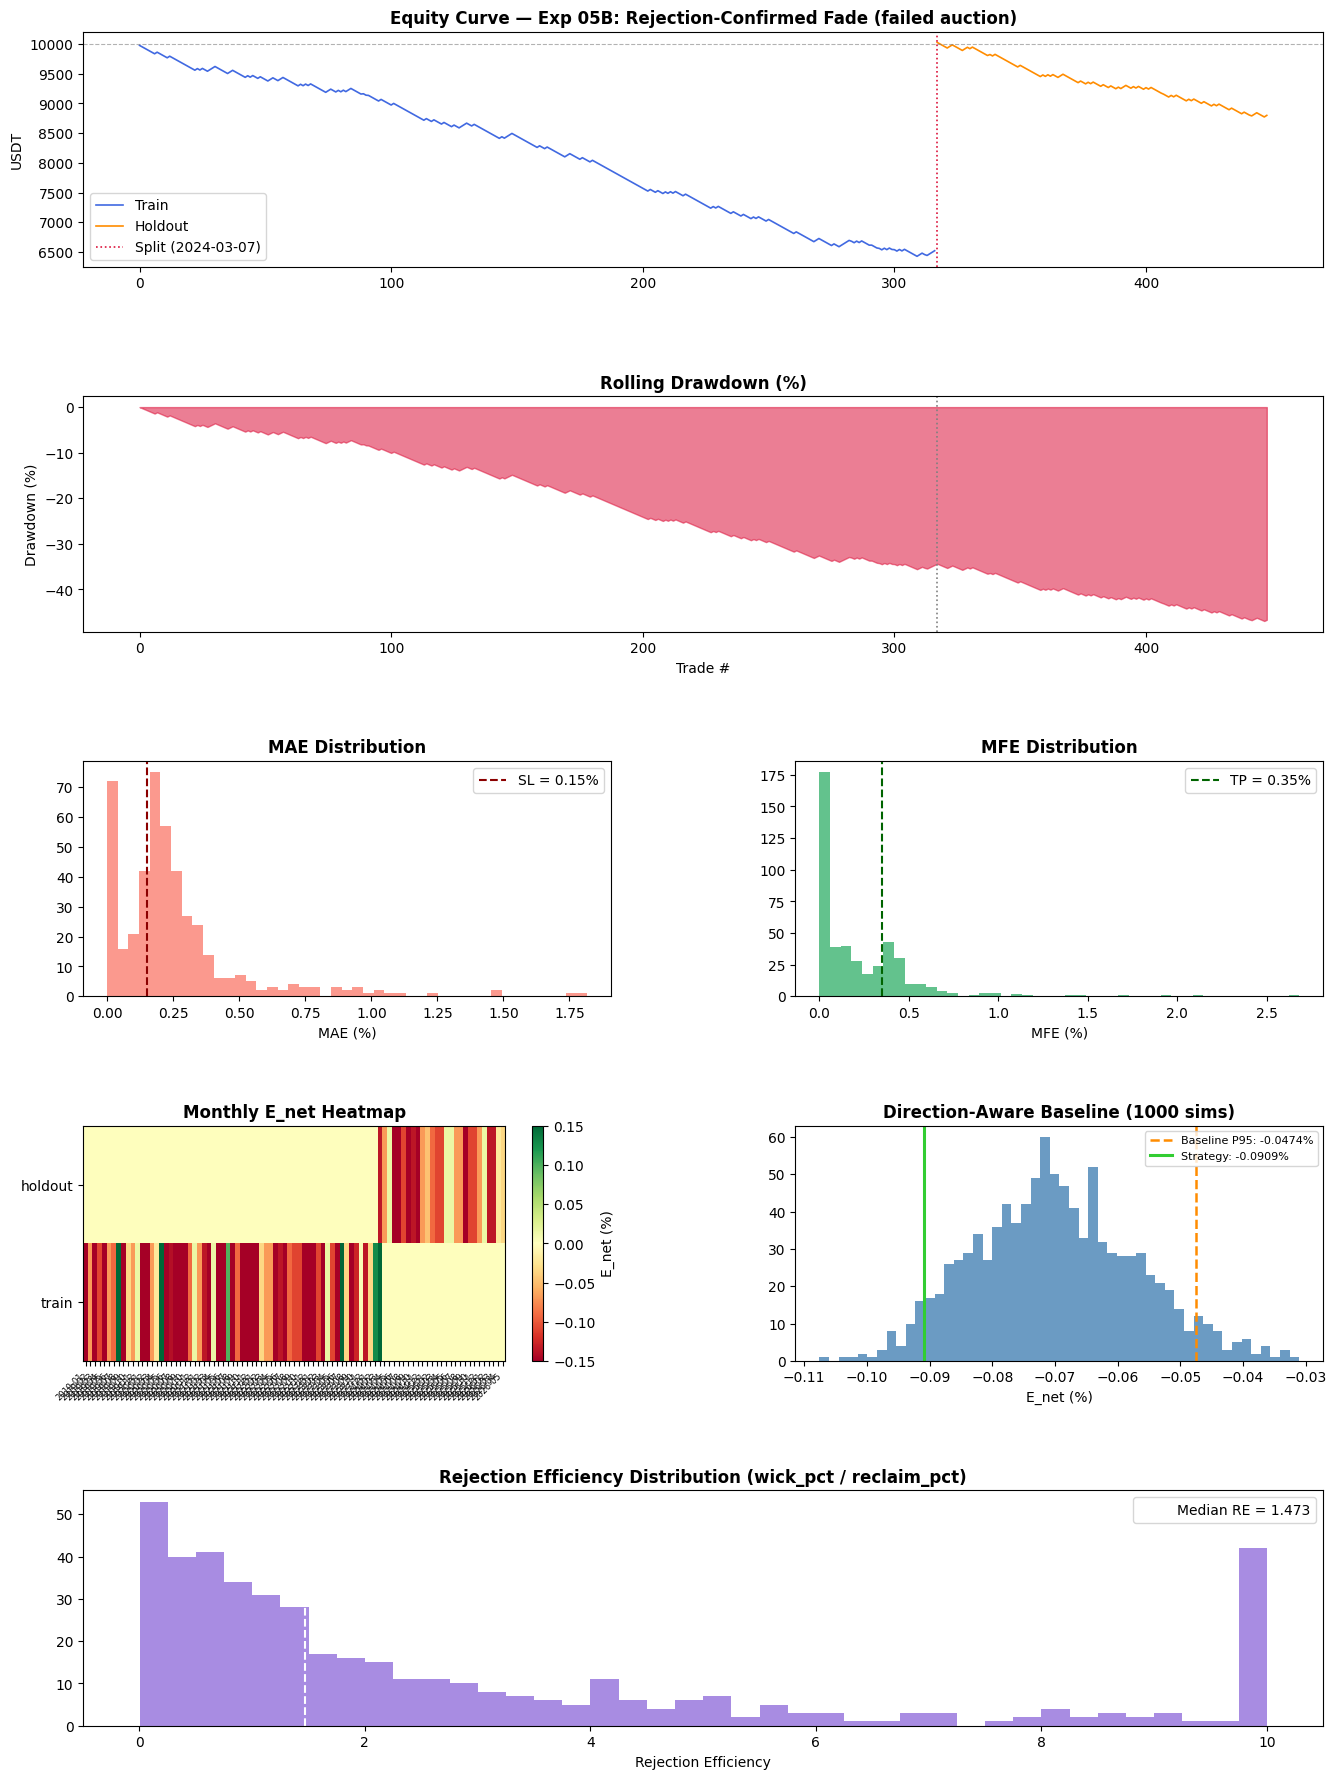

Saved: outputs/05b_visualizations.png


In [15]:
if len(equity_all) == 0:
    print('No trades — skip visualizations')
else:
    fig = plt.figure(figsize=(16, 22))
    gs  = GridSpec(5, 2, figure=fig, hspace=0.55, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, :])
    if len(equity_train):
        ax1.plot(range(len(equity_train)), equity_train['equity_usdt'],
                 color='royalblue', lw=1.2, label='Train')
    if len(equity_hold):
        ax1.plot(range(len(equity_train), len(equity_train)+len(equity_hold)),
                 equity_hold['equity_usdt'], color='darkorange', lw=1.2, label='Holdout')
    ax1.axhline(FROZEN_PARAMS['capital_usdt'], color='gray', ls='--', lw=0.8, alpha=0.6)
    ax1.axvline(len(equity_train), color='crimson', ls=':', lw=1.2, label='Split (2024-03-07)')
    ax1.set_title('Equity Curve — Exp 05B: Rejection-Confirmed Fade (failed auction)', fontweight='bold')
    ax1.set_ylabel('USDT'); ax1.legend()

    ax2 = fig.add_subplot(gs[1, :])
    ax2.fill_between(range(len(equity_all)), equity_all['rolling_drawdown_pct'], 0,
                     alpha=0.55, color='crimson')
    ax2.axvline(len(equity_train), color='gray', ls=':', lw=1.2)
    ax2.set_title('Rolling Drawdown (%)', fontweight='bold')
    ax2.set_ylabel('Drawdown (%)'); ax2.set_xlabel('Trade #')

    ax3 = fig.add_subplot(gs[2, 0])
    ax3.hist(trades['mae_pct'] * 100, bins=45, color='salmon', edgecolor='none', alpha=0.8)
    ax3.axvline(FROZEN_PARAMS['sl_pct'] * 100, color='darkred', ls='--', lw=1.5,
                label=f"SL = {FROZEN_PARAMS['sl_pct']*100:.2f}%")
    ax3.set_title('MAE Distribution', fontweight='bold')
    ax3.set_xlabel('MAE (%)'); ax3.legend()

    ax4 = fig.add_subplot(gs[2, 1])
    ax4.hist(trades['mfe_pct'] * 100, bins=45, color='mediumseagreen', edgecolor='none', alpha=0.8)
    ax4.axvline(FROZEN_PARAMS['tp_pct'] * 100, color='darkgreen', ls='--', lw=1.5,
                label=f"TP = {FROZEN_PARAMS['tp_pct']*100:.2f}%")
    ax4.set_title('MFE Distribution', fontweight='bold')
    ax4.set_xlabel('MFE (%)'); ax4.legend()

    ax5 = fig.add_subplot(gs[3, 0])
    if len(monthly) > 0:
        try:
            mp = monthly.pivot(index='split', columns='month', values='expectancy_pct').fillna(0)
            im = ax5.imshow(mp.values, aspect='auto', cmap='RdYlGn', vmin=-0.15, vmax=0.15)
            ax5.set_xticks(range(len(mp.columns)))
            ax5.set_xticklabels(mp.columns, rotation=45, ha='right', fontsize=6)
            ax5.set_yticks(range(len(mp.index))); ax5.set_yticklabels(mp.index)
            plt.colorbar(im, ax=ax5, label='E_net (%)')
        except Exception as e:
            ax5.text(0.5, 0.5, str(e), ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('Monthly E_net Heatmap', fontweight='bold')

    ax6 = fig.add_subplot(gs[3, 1])
    ax6.hist(baseline_dist * 100, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax6.axvline(baseline_p95 * 100, color='darkorange', ls='--', lw=1.8,
                label=f'Baseline P95: {baseline_p95*100:.4f}%')
    ax6.axvline(strategy_e_net * 100, color='limegreen', ls='-', lw=2.2,
                label=f'Strategy: {strategy_e_net*100:.4f}%')
    ax6.set_title('Direction-Aware Baseline (1000 sims)', fontweight='bold')
    ax6.set_xlabel('E_net (%)'); ax6.legend(fontsize=8)

    ax7 = fig.add_subplot(gs[4, :])
    re_vals = trades[trades['rej_efficiency'] > 0]['rej_efficiency']
    if len(re_vals) > 10:
        ax7.hist(re_vals.clip(upper=10), bins=40, color='mediumpurple', edgecolor='none', alpha=0.8)
        ax7.axvline(re_vals.median(), color='white', ls='--', lw=1.5,
                    label=f'Median RE = {re_vals.median():.3f}')
        ax7.set_title('Rejection Efficiency Distribution (wick_pct / reclaim_pct)', fontweight='bold')
        ax7.set_xlabel('Rejection Efficiency'); ax7.legend()
    else:
        ax7.text(0.5, 0.5, 'Insufficient RE data', ha='center', va='center', transform=ax7.transAxes)

    plt.savefig(OUTPUT_DIR / '05b_visualizations.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/05b_visualizations.png')

In [16]:
# ── Go / No-Go Decision ────────────────────────────────────────────────────────
e_net_hold = compute_expectancy(holdout_pnl)
n_hold     = len(trades[trades['split']=='holdout'])
ci_lo      = holdout_metrics.get('expectancy_ci_95_lo_pct', 0) / 100

required = {
    'E_net > 0':                      e_net_hold > 0,
    'n_trades >= 100':                n_hold >= 100,
    'CI_95_lower > -0.02%':           ci_lo > -0.0002,
    'strategy_E_net > baseline_P95':  strategy_e_net > baseline_p95,
}

e_train_val      = compute_expectancy(train_pnl)
_holdout_monthly = monthly[monthly['split'] == 'holdout'] if len(monthly) else pd.DataFrame()
advisory = {
    'train->holdout degradation < 50%': (
        abs(e_train_val - e_net_hold) / abs(e_train_val) < 0.5
        if abs(e_train_val) > 1e-9 else False
    ),
    'monthly E_net positive >= 6/12 (holdout)': (
        int((_holdout_monthly['expectancy_pct'] > 0).sum()) >= 6
        if len(_holdout_monthly) > 0 else False
    ),
    'max_drawdown < 20%': (
        equity_all['rolling_drawdown_pct'].min() > -20.0 if len(equity_all) else False
    ),
    'win_rate > 55%': (
        (trades['pnl_net_pct'] > 0).mean() > 0.55 if len(trades) else False
    ),
    'avg_MAE < SL (entry precision improved)': (
        trades['mae_pct'].mean() < FROZEN_PARAMS['sl_pct'] if len(trades) else False
    ),
}

all_pass = all(required.values())
verdict  = 'GO' if all_pass else 'NO-GO'

SEP = '=' * 60
print(SEP)
print(f'  EXPERIMENT 05B — REJECTION-CONFIRMED FADE (failed auction)')
print(f'  Dataset: BTCUSDT M5, 2019-01-01 → 2026-05-25')
print(f'  SPEC_HASH : {SPEC_HASH}')
print(f'  VERDICT   : {verdict}  {"(ALL required pass)" if all_pass else "(some required FAIL)"}')
print(SEP)
print('\n  Required (all must pass):')
for k, v in required.items():
    print(f'    {"PASS" if v else "FAIL"}  {k}')
print('\n  Advisory (informational):')
for k, v in advisory.items():
    print(f'    {"OK  " if v else "WARN"}  {k}')
print(SEP)

if len(trades[trades['split']=='holdout']) > 0:
    h = trades[trades['split']=='holdout']
    print('\n  Experiment progression (holdout):')
    print(f'    {"Metric":<28} {"Exp03 M5":>9} {"Exp04 M5":>9} {"Exp05A M5":>9} {"Exp05B M5":>9}')
    metrics_hist = [
        ('E_net %',      -0.0628, -0.0924, -0.0666, compute_expectancy(holdout_pnl)*100),
        ('Win Rate',      0.3517,  0.2823,  0.3374, (holdout_pnl > 0).mean()),
        ('avg_MAE %',    0.1644,  0.1934,  0.1894, h['mae_pct'].mean()*100),
        ('avg_MFE %',    0.1849,  0.2087,  0.2424, h['mfe_pct'].mean()*100),
        ('avg_hold(c)',  1.3,     5.181,   5.402,  h['holding_candles'].mean()),
        ('n_trades',     290,     248,     246,    n_hold),
    ]
    for name, e03, e04, e05a, e05b in metrics_hist:
        print(f'    {name:<28} {e03:>9.3f} {e04:>9.3f} {e05a:>9.3f} {e05b:>9.3f}')
    print(SEP)

# ── Save artifacts ─────────────────────────────────────────────────────────────
if len(trades):
    trades.to_csv(OUTPUT_DIR / '05b_trades.csv', index=False)

metrics_out = {
    'spec_hash': SPEC_HASH, 'verdict': verdict,
    'train': train_metrics, 'holdout': holdout_metrics,
    'required_checks': {k: bool(v) for k, v in required.items()},
    'advisory_checks': {k: bool(v) for k, v in advisory.items()},
    'infrastructure': {
        'bootstrap_block': BOOTSTRAP_BLOCK,
        'split_date': '2024-03-07',
        'dataset': 'BTCUSDT_M5.csv',
        'signal_change': 'touch_reaction -> rejection_confirmation (high>asia_high, close<asia_high)',
    }
}
with open(OUTPUT_DIR / '05b_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_out, f, indent=2, default=str)

print('\n  Artifacts:')
for fname in ['05b_trades.csv', '05b_equity.csv', '05b_metrics.json',
              '05b_baseline_dist.csv', '05b_visualizations.png']:
    path = OUTPUT_DIR / fname
    size = path.stat().st_size if path.exists() else 0
    print(f'    {fname}  ({size:,} bytes)' if size else f'    {fname}  (pending)')

  EXPERIMENT 05B — REJECTION-CONFIRMED FADE (failed auction)
  Dataset: BTCUSDT M5, 2019-01-01 → 2026-05-25
  SPEC_HASH : b1325240c0f4
  VERDICT   : NO-GO  (some required FAIL)

  Required (all must pass):
    FAIL  E_net > 0
    PASS  n_trades >= 100
    FAIL  CI_95_lower > -0.02%
    FAIL  strategy_E_net > baseline_P95

  Advisory (informational):
    OK    train->holdout degradation < 50%
    WARN  monthly E_net positive >= 6/12 (holdout)
    WARN  max_drawdown < 20%
    WARN  win_rate > 55%
    WARN  avg_MAE < SL (entry precision improved)

  Experiment progression (holdout):
    Metric                        Exp03 M5  Exp04 M5 Exp05A M5 Exp05B M5
    E_net %                         -0.063    -0.092    -0.067    -0.091
    Win Rate                         0.352     0.282     0.337     0.288
    avg_MAE %                        0.164     0.193     0.189     0.210
    avg_MFE %                        0.185     0.209     0.242     0.197
    avg_hold(c)                      1.300     5